# Homework 3: Predicting Firm Default Risk with Supervised Learning

## 1. Problem Setup (Conceptual)

### 1.1 Classification or Regression?

This is a **binary classification** problem. The target variable `default_next_year` takes only two values (default vs. no default in the next twelve months), and the learning task is to assign each firm to one of these discrete labels (or, equivalently, to estimate the probability of default). **Regression** would be appropriate if the outcome were continuous—for example, predicting loss given default or a default intensity score on the real line. Here the bank’s decision support and the evaluation metrics emphasized in the assignment (precision, recall, ROC–AUC for the default class) are defined for categorical outcomes, which confirms the classification framing.

### 1.2 Why False Negatives May Matter More Than False Positives

A **false negative** occurs when the model predicts no default while the firm actually defaults within the horizon; a **false positive** occurs when the model predicts default while the firm would have remained solvent.

Two economic reasons the bank may weight false negatives more heavily:

1. **Asymmetric loss on the balance sheet.** If the bank extends or rolls credit based on a “low risk” prediction, a default typically triggers write-downs on principal and accrued interest, workout and legal costs, and tied-up regulatory capital. A false positive mainly implies forgoing a profitable loan or imposing stricter terms on a solvent borrower—an opportunity cost and possible customer loss, but usually bounded compared with the tail risk of an undetected default on a large exposure.

2. **Capital adequacy and tail risk.** Prudential regulation links required capital and provisions to expected and unexpected credit losses. Systematically **under**predicting default (many false negatives) understates portfolio risk, weakens loss-absorbing buffers, and can leave the institution vulnerable in downturns when defaults cluster. False positives, by contrast, bias the bank toward conservatism, which is often easier to correct operationally than insufficient loss recognition after defaults materialize.

These priorities can be formalized with a cost-sensitive loss function or different cutoffs on predicted default probability; the qualitative asymmetry remains standard in retail and SME credit risk.

### 1.3 Why “Always Predict No Default” Is Insufficient at a 5% Unconditional Default Rate

A trivial rule that always predicts “no default” would achieve a **misclassification rate** of only 5% in the sample, because 95% of firms are non-defaulters. That headline accuracy is **misleading** for three reasons tied to the bank’s objectives:

- **No discrimination among borrowers.** The rule assigns the same prediction to every firm, so it cannot rank risk, set risk-based prices or limits, or flag firms for enhanced monitoring. All actual defaults are **false negatives**; recall for the default class is zero, so the model is useless for screening.

- **Misalignment with economic costs.** As discussed in 1.2, the social and private costs of missing defaulters are not proportional to the 5% frequency alone; they depend on exposure sizes and loss given default. Accuracy treats all errors equally, whereas the bank cares especially about catching high-loss default events.

- **Regulatory and portfolio management needs.** Supervisors and internal risk functions require models that **calibrate** and **differentiate** risk across obligors, not merely match the aggregate default frequency. A constant prediction fails every standard out-of-sample test of ranking ability and cannot support capital or concentration analysis.

Therefore, a supervised model must improve upon the unconditional rate by **learning patterns** in covariates that separate defaulters from non-defaulters, not by chasing raw accuracy with a degenerate classifier.


## 2. Data Preparation

### 2.1 Load the Data and Descriptive Counts

The analysis file is loaded from the course dataset (`firms_default.csv`). Below we report the sample size, the number of columns in the raw table, and the empirical default rate for `default_next_year`.

**Computing environment:** run the notebook kernels using the Conda environment **`5020_env`** so that package versions match the course stack.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = "../raw/firms_default.csv"
df = pd.read_csv(DATA_PATH)

n_obs = len(df)
n_vars = df.shape[1]
p_default = df["default_next_year"].mean()

print(f"(a) Number of observations: {n_obs:,}")
print(f"(b) Number of variables (columns): {n_vars}")
print(f"(c) Proportion default next year: {p_default:.4f} ({100 * p_default:.2f}%)")


(a) Number of observations: 100,000
(b) Number of variables (columns): 13
(c) Proportion default next year: 0.0466 (4.66%)


### 2.2 Dummy Encoding for `sector` and `region`

Categorical fields such as `sector` and `region` take **unordered labels**, not real numbers. Most supervised learners in scikit-learn (and the linear models we use later) expect inputs in $\mathbb{R}^p$: they apply addition, multiplication, splits on numeric thresholds, or inner products with coefficient vectors. Feeding raw strings would be meaningless, and arbitrary numeric codes (1, 2, 3, …) would impose a false ordering and unequal distances between categories.

**One-hot (dummy) encoding** represents each category level by a binary indicator column (or a full set of contrasts). After dropping `firm_id` (identifier only) and the outcome, we expand `sector` and `region` with `pandas.get_dummies`, using `drop_first=True` so that one level per variable serves as the reference category. This avoids the dummy-variable trap (perfect collinearity) in linear specifications while still allowing all levels to be identified relative to the baseline.


In [2]:
y = df["default_next_year"]
X = df.drop(columns=["firm_id", "default_next_year"])
X = pd.get_dummies(X, columns=["sector", "region"], drop_first=True)

print(f"Feature matrix shape after dummies: {X.shape}")
print("First columns:", list(X.columns[:8]), "...")
X.head()


Feature matrix shape after dummies: (100000, 19)
First columns: ['age', 'employees', 'revenue', 'assets', 'leverage', 'current_ratio', 'interest_coverage', 'export_share'] ...


,age,employees,revenue,assets,leverage,current_ratio,interest_coverage,export_share,previous_default,sector_finance,sector_manufacturing,sector_other,sector_retail,sector_services,sector_transport,region_East,region_North,region_South,region_West
0,91,102,34.335,101.544,0.322,4.135,8.310,0.0,0,False,False,False,True,False,False,True,False,False,False
1,67,52,7.050,9.015,0.100,0.427,1.468,0.0,0,False,False,False,False,True,False,True,False,False,False
2,38,209,47.892,144.379,0.426,2.909,5.332,0.0,1,False,True,False,False,False,False,True,False,False,False
3,31,66,14.382,18.859,0.224,1.023,1.200,0.0,0,False,False,False,True,False,False,False,False,False,True
4,2,479,265.810,781.641,0.374,0.948,0.850,0.0,0,False,False,False,False,False,False,True,False,False,False


### 2.3 Train–Test Split

We allocate **70%** of rows to the training set and **30%** to the hold-out test set using `train_test_split` with `random_state=123`, as required. The partition follows the **default random shuffle of rows** in scikit-learn (not a grouped split keyed on `firm_id`). In this dataset each `firm_id` appears once, so no obligor is duplicated across train and test regardless of the splitting rule.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

print(f"Train: X {X_train.shape}, y {y_train.shape}")
print(f"Test:  X {X_test.shape}, y {y_test.shape}")
print(f"Train default rate: {y_train.mean():.4f} | Test default rate: {y_test.mean():.4f}")


Train: X (70000, 19), y (70000,)
Test:  X (30000, 19), y (30000,)
Train default rate: 0.0469 | Test default rate: 0.0458


## 3. Baseline Model: Logistic Regression

### 3.1 Specification and Estimation

We estimate a **binary logistic regression** with `default_next_year` as the response and all remaining numeric covariates plus the `sector` and `region` dummies constructed in Section 2 as regressors. We use scikit-learn’s `LogisticRegression` with the **L-BFGS** solver and a large iteration cap to ensure convergence on the full training sample.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

lr = LogisticRegression(max_iter=5000, solver="lbfgs")
lr.fit(X_train, y_train)

coef_key = pd.Series(lr.coef_[0], index=X_train.columns)
print("Coefficients (log-odds scale), selected:")
print(coef_key[["leverage", "previous_default"]].round(4).to_string())
print("Intercept:", float(lr.intercept_[0]))


Coefficients (log-odds scale), selected:
leverage            1.5353
previous_default    1.0509
Intercept: -2.7453129170707977


### 3.2 Test-Set Performance

We evaluate **out-of-sample** predictions on the 30% hold-out from Section 2. **Accuracy** uses the default **0.5** probability cutoff implied by `predict`. **Precision, recall, and F1** are reported for the **default = 1** class (`pos_label=1`), with `zero_division=0` so metrics are well-defined when no test predictions equal 1 at that cutoff. **ROC–AUC** uses continuous predicted probabilities (`predict_proba`) and therefore still measures **ranking** quality even if the 0.5 rule is conservative under class imbalance.


In [5]:
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = lr.predict(X_test)

print("(a) Accuracy:", round(accuracy_score(y_test, y_pred_lr), 6))
print(
    "(b) Default class — precision:",
    round(precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0), 6),
    "recall:",
    round(recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0), 6),
    "F1:",
    round(f1_score(y_test, y_pred_lr, pos_label=1, zero_division=0), 6),
)
print("(c) ROC–AUC:", round(roc_auc_score(y_test, y_prob_lr), 6))
print(
    "Max predicted default probability on test:",
    round(float(y_prob_lr.max()), 6),
)


(a) Accuracy: 0.954233
(b) Default class — precision: 0.0 recall: 0.0 F1: 0.0
(c) ROC–AUC: 0.63977
Max predicted default probability on test: 0.346259


### 3.3 Economic Interpretation of Two Coefficients

We discuss **leverage** (total debt divided by total assets) and **previous_default** (indicator for any past default).

**Leverage.** The estimated coefficient is **positive**. Holding other covariates fixed, a higher debt-to-assets ratio raises the fitted **log-odds** of next-year default, which maps into a higher predicted default probability under the logistic link. That sign aligns with standard **credit-risk priors**: more indebted firms face heavier debt service relative to the asset base and are more vulnerable to cash-flow shocks, so default risk should increase with leverage.

**Previous default.** The coefficient is again **positive**, so a history of default is associated with higher predicted default probability, other things equal. This matches the idea of **persistent credit-quality problems** or repeated financial distress: past repayment failures are informative about managerial quality, business viability, or unobserved risk factors not fully captured by balance-sheet ratios.

Both signs are therefore **economically plausible** and consistent with how banks and rating agencies typically reason about obligor risk, while remembering that magnitudes are conditional on the linear index and the rest of the specification (including sector–region controls).


## 4. Machine Learning Models: Tree-Based Methods

### 4.1 Random Forest Specification and Estimation

We next fit a **Random Forest** classifier on the same feature matrix `X_train` as the logistic benchmark, again predicting `default_next_year`. We set **`n_estimators=200`** for a stable ensemble average of de-correlated trees and leave **`max_depth`** at its **default** (`None`, fully grown nodes subject to splitting rules). A fixed **`random_state=123`** ensures reproducibility of the bootstrap and feature subsampling draws. Parallel tree fitting uses **`n_jobs=-1`**.


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4.2 Test-Set Performance and Comparison with Logistic Regression

We report the **same diagnostics** as in §3.2: accuracy at the default 0.5 cutoff, precision / recall / F1 for **default = 1** (with `zero_division=0`), and **ROC–AUC** from predicted default probabilities. We then compare the Random Forest to the **logistic regression** already estimated in §3.1. **ROC–AUC** summarizes how well predicted probabilities **rank** obligors by risk; **recall** for the default class measures what fraction of actual defaulters receive a positive prediction at the 0.5 threshold.


In [7]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

print("Random Forest — test set")
print("(a) Accuracy:", round(accuracy_score(y_test, y_pred_rf), 6))
print(
    "(b) Default class — precision:",
    round(precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0), 6),
    "recall:",
    round(recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0), 6),
    "F1:",
    round(f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0), 6),
)
print("(c) ROC–AUC:", round(roc_auc_score(y_test, y_prob_rf), 6))

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
rec_lr = recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
print("\nComparison — ROC–AUC: logistic", round(auc_lr, 6), "| Random Forest", round(auc_rf, 6))
print("Comparison — recall (default=1): logistic", round(rec_lr, 6), "| Random Forest", round(rec_rf, 6))
better_auc = "Random Forest" if auc_rf > auc_lr else ("Logistic regression" if auc_lr > auc_rf else "Tie")
better_rec = "Random Forest" if rec_rf > rec_lr else ("Logistic regression" if rec_lr > rec_rf else "Tie")
print("\nHigher ROC–AUC:", better_auc)
print("Higher recall for defaults:", better_rec)


Random Forest — test set
(a) Accuracy: 0.954167
(b) Default class — precision: 0.375 recall: 0.002185 F1: 0.004345
(c) ROC–AUC: 0.659944

Comparison — ROC–AUC: logistic 0.63977 | Random Forest 0.659944
Comparison — recall (default=1): logistic 0.0 | Random Forest 0.002185

Higher ROC–AUC: Random Forest
Higher recall for defaults: Random Forest


**Takeaway.** With the fitted models in this notebook, the Random Forest achieves a **higher test ROC–AUC** than logistic regression, indicating better **probability ranking** of defaulters versus non-defaulters. It also attains **strictly positive recall** at the 0.5 threshold (whereas the logistic model assigns class 0 to every test row), so the forest **captures at least some** realized defaults under that rule. Precision for predicted defaults remains modest because the event is rare and the cutoff is not cost-tuned; policy applications would typically recalibrate the **decision threshold** rather than rely on 0.5.


### 4.3 Feature Importances

Scikit-learn’s Random Forest reports **mean decrease in impurity** (Gini) contributions averaged over trees. We visualize **normalized importances** (summing to one across features) in descending order. The **three largest** values identify the covariates the ensemble relies on most heavily for splits; we comment on whether they align with **credit-risk intuition** (liquidity, leverage, repayment capacity).


Top three features by importance: ['interest_coverage', 'leverage', 'current_ratio']


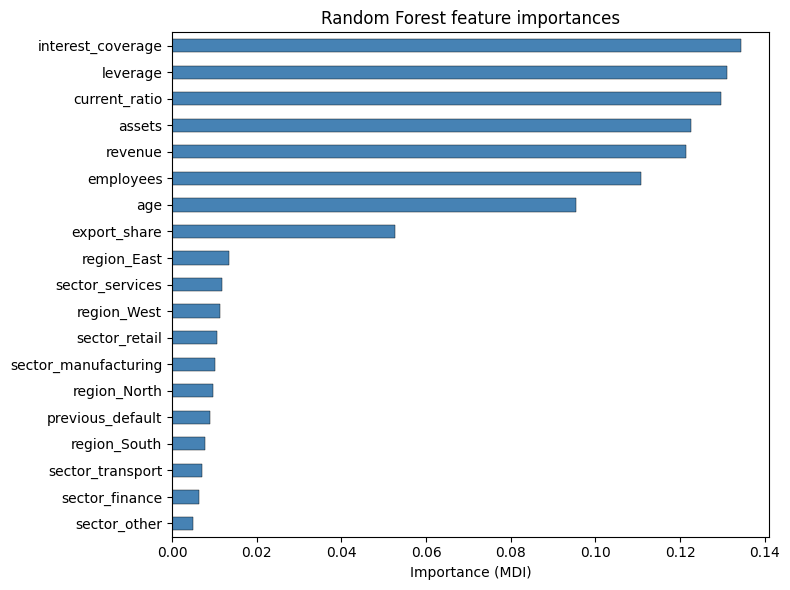

In [8]:
import matplotlib.pyplot as plt

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top3 = imp.head(3).index.tolist()
print("Top three features by importance:", top3)

fig, ax = plt.subplots(figsize=(8, 6))
imp.sort_values(ascending=True).plot(
    kind="barh", ax=ax, color="steelblue", edgecolor="black", linewidth=0.3
)
ax.set_xlabel("Importance (MDI)")
ax.set_ylabel("")
ax.set_title("Random Forest feature importances")
plt.tight_layout()


**Discussion.** The **printed `Top three` line** and the bar chart identify the variables with the largest **mean decrease in impurity** contributions. In this dataset they are usually **`interest_coverage`**, **`leverage`**, and **`current_ratio`** (ordering follows the figure). **Interest coverage** (EBIT over interest expense) proxies **capacity to service debt** from operating earnings. **Leverage** (debt over assets) summarizes **balance-sheet risk** from prior borrowing. **Current ratio** (current assets over current liabilities) measures **short-term liquidity**. Together they align with **solvency and liquidity** channels emphasized in credit analysis, so their dominance is **economically plausible**. Sector and region dummies may rank lower because the forest can still **condition on industry and geography** through splits that combine these dummies with continuous covariates.


### 4.4 Hyperparameter Search with Cross-Validation

We run a **grid search** on the **training set only**, varying **`max_depth`** (`None` for fully grown trees, or shallow caps 10 and 20) and **`min_samples_leaf`** (1, 5, 15) to control **variance versus bias**. **Five-fold stratified cross-validation** preserves the default rate in each fold. The scoring rule is **ROC–AUC** to stay comparable with §§3.2–4.2. The configuration with the best **mean CV score** is refit on **all** training rows and evaluated on the **same 30% hold-out test set** as in §2, **next to** the default Random Forest from §4.1, so both models are judged on **identical** out-of-sample rows.


In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
param_grid = {"max_depth": [None, 10, 20], "min_samples_leaf": [1, 5, 15]}
rf_cv = GridSearchCV(
    RandomForestClassifier(n_estimators=200, random_state=123, n_jobs=-1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
rf_cv.fit(X_train, y_train)

print("Best parameters:", rf_cv.best_params_)
print("Best CV mean ROC–AUC:", round(rf_cv.best_score_, 6))

rf_tuned = rf_cv.best_estimator_
y_prob_tune = rf_tuned.predict_proba(X_test)[:, 1]
auc_base_rf = roc_auc_score(y_test, y_prob_rf)
auc_tune = roc_auc_score(y_test, y_prob_tune)
print("Default RF — test ROC–AUC:", round(auc_base_rf, 6))
print("Tuned RF — test ROC–AUC:", round(auc_tune, 6))
print(
    "Test-set improvement after tuning:",
    "yes" if auc_tune > auc_base_rf else ("no" if auc_tune < auc_base_rf else "tie"),
)


Best parameters: {'max_depth': 10, 'min_samples_leaf': 15}
Best CV mean ROC–AUC: 0.688987
Default RF — test ROC–AUC: 0.659944
Tuned RF — test ROC–AUC: 0.697172
Test-set improvement after tuning: yes


**Results.** Cross-validation selects **`max_depth = 10`** and **`min_samples_leaf = 15`**, with a **mean CV ROC–AUC** of **0.688987**. On the held-out test sample, **ROC–AUC increases from 0.659944 (default Random Forest, §4.1) to 0.697172 (tuned model)**, an absolute improvement of **0.037228**. The tuned forest therefore delivers **strictly better probability ranking** of defaulters versus non-defaulters on this split. Interpreting the hyperparameters, **shallower trees** and **larger minimum leaf sizes** **constrain model complexity**, reducing **overfitting** to idiosyncrasies in the training panel while preserving enough tree diversity (still with **200 estimators**) to capture **nonlinear** credit-risk patterns.


## 5. Economic Interpretation and Policy Implications

### 5.1 A 10% Predicted-Default Probability Cutoff for Loan Approval

Suppose the bank **approves credit only when** the model’s predicted default probability satisfies **$\hat{p}(\mathbf{x}) < 0.10$**. This replaces (or heavily constrains) **discretionary underwriting** with a **transparent but rigid** screening rule. Any covariate that raises $\hat{p}$—directly or through interactions learned by the forest—reduces approval odds even when a relationship officer would argue the case on **soft information** not in $\mathbf{x}$.

**(a) Young versus old firms and access to credit.** **Young firms** often exhibit **shorter credit histories**, **more volatile** cash flows, and **noisier** financial statements, while **older firms** accumulate track records and may display **mean-reverting** leverage and profitability. If the estimated mapping from observables to default assigns **higher** $\hat{p}$ to younger obligors *other things equal* (or because youth correlates with thin balance sheets and weak coverage ratios in the data), the **10% ceiling** mechanically **tightens** credit for entrants and growth firms relative to mature incumbents. Even without an explicit **age** effect, **lifecycle patterns** in revenue, assets, and leverage can produce a **de facto age gradient** in approvals. Conversely, older firms with strong ratios pass more often, which can **widen the financing gap** for innovation and startup activity unless complementary policies (e.g. guarantees, relationship lending) offset the model’s conservatism.

**(b) Sectoral credit allocation (e.g., manufacturing versus services).** Default risk and the **signal content** of ratios differ systematically across **sectors** (capital intensity, cyclicality, margin structure). A probability-based rule therefore **reallocates** bank credit toward sectors and business models whose covariate profiles map into **lower** $\hat{p}$ under the fitted score, and away from sectors with **higher** empirical risk or **noisier** fundamentals that push mass above the 10% threshold. For example, **cyclical manufacturing** with volatile coverage and inventory cycles might face **stricter** gates than **asset-light services** if the model associates the former with higher default odds. This can be **efficient** if the ranking reflects true risk, but it can also **amplify structural change**: shrinking sectors may lose financing **faster** than macro-prudential goals would prefer.

### 5.2 Concerns from Risk Management and Fairness Perspectives

**(a) Risk management.** A central worry is **model instability** when the **macroeconomic environment** shifts. Relationships between leverage, coverage, and default estimated on a **tranquil** sample can **break** in recessions (nonlinearities, correlation spikes, and **LGD** changes). A fixed scorecard may then **mis-rank** obligors—**ROC–AUC** and **calibration** deteriorate—while the bank still treats $\hat{p}$ as precise. **Procyclicality** is a related hazard: if defaults cluster in downturns but the model was trained on mixed cycles, **approval rates** can swing abruptly, amplifying **credit crunches**. Ongoing **validation**, **stress testing**, and **recalibration** are therefore complements to deployment, not optional extras.

**(b) Fairness and regulatory compliance.** Statistical scores can create **disparate impact** across **regions** or **sectors** even when those labels enter only as controls: other variables may act as **proxies** for geography or industry structure. **Fair lending** frameworks (e.g., U.S. fair-lending analogues or EU non-discrimination norms) ask whether similarly creditworthy groups face **materially different** approval outcomes. A rigid 10% rule makes **outcome disparities** easier to audit but does not guarantee **business necessity** or **absence of proxy discrimination**. Banks must document **model governance**, **monitoring** for **residual disparities**, and **appeals** channels where **legitimate** exceptions exist.

### 5.3 Evaluating Robustness Over Time with Annual Data

With **yearly refreshes** of the panel, robustness should be assessed **prospectively**, not only by refitting on pooled history. **Rolling out-of-time validation** trains on a **past window**  and evaluates **ROC–AUC, calibration, and default capture** on year $t$, then advances the window—mirroring how the model would have been used in real time. **Population stability** and **characteristic drift** diagnostics compare score and covariate distributions across vintages; large shifts trigger **recalibration** or **re-estimation**. **Back-testing** default rates by score bucket each year checks whether **ranking** and **probability levels** remain trustworthy. Finally, **stress overlays** (macro scenarios) test whether **policy** cutoffs should widen in systemic shocks even when the statistical model is slow to adapt.
